In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df =pd.read_csv("/Users/ashleyyang/Desktop/DS Capstone/Week5/tmpwmdgd3ai.csv")
print(df.columns)
print(df.head(2))

/var/folders/nx/r0kn3t8x44x3r0j6v3nxvsp40000gn/T/ipykernel_9718/2502812233.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df =pd.read_csv("/Users/ashleyyang/Desktop/DS Capstone/Week5/tmpwmdgd3ai.csv")


Index(['businessname', 'dbaname', 'legalowner', 'namelast', 'namefirst',
       'licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',
       'descript', 'result', 'resultdttm', 'violation', 'viol_level',
       'violdesc', 'violdttm', 'viol_status', 'status_date', 'comments',
       'address', 'city', 'state', 'zip', 'property_id', 'location'],
      dtype='object')
         businessname dbaname    legalowner         namelast   
0  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC  \
1  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   

              namefirst  licenseno                 issdttm   
0  Kenneth Pasquariello     313440  2017-08-14 12:49:37+00  \
1  Kenneth Pasquariello     313440  2017-08-14 12:49:37+00   

                  expdttm licstatus licensecat  ...                violdttm   
0  2020-01-01 04:59:00+00  Inactive         FS  ...  2018-03-20 14:54:25+00  \
1  2020-01-01 04:59:00+00  Inactive         FS  ...  2018-03-20 14:54:25+00   

  vio

     month  rodent_violation
0  2006-04                 0
1  2006-08                 0
2  2006-10                 0
3  2006-11                 0
4  2006-12                 0
       month  rodent_violation
230  2025-10                72
231  2025-11                60
232  2025-12                67
233  2026-01                63
234  2026-02                28


/var/folders/nx/r0kn3t8x44x3r0j6v3nxvsp40000gn/T/ipykernel_9718/878162775.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['inspection_date'].dt.to_period('M')


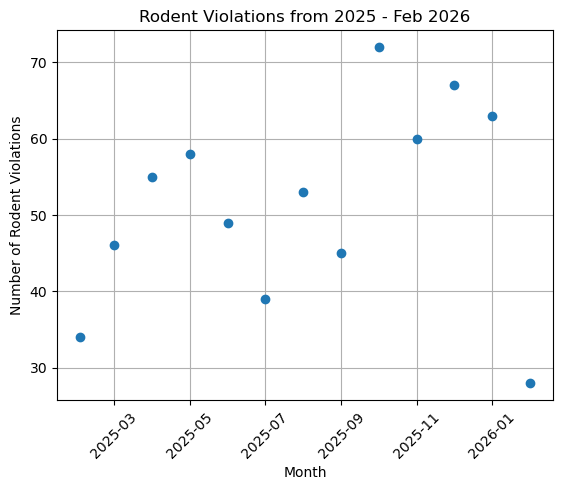

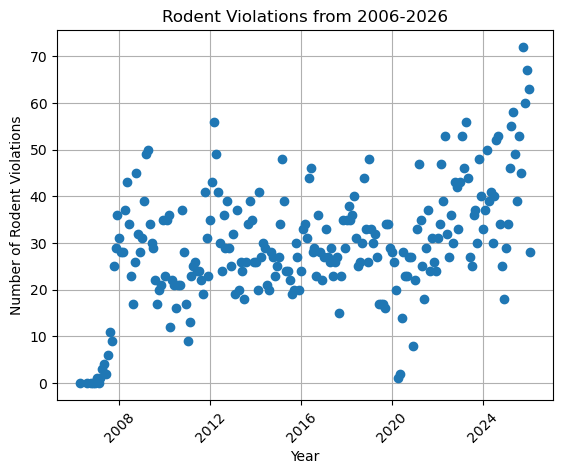

In [19]:
#create col that indicates whether the violation is related to rodents
df['rodent_violation'] = df['comments'].apply(lambda x: 1 if 'rodent' in str(x).lower() else 0)
#create a new dataframe of each month in this dataset and the number of rodent violations in that month
df['inspection_date'] = pd.to_datetime(df['resultdttm'], format='ISO8601') #need ISO8601 for milliseconds
df['month'] = df['inspection_date'].dt.to_period('M')
restaurant_month = (
    df.groupby(['businessname', 'month'])['rodent_violation'] #grouping by business name and month to ensure that there is no double counting
      .max()
      .reset_index()
)
rodent_violations_by_month = restaurant_month.groupby('month')['rodent_violation'].sum().reset_index()

#let's not count 2006 -- contains many missing months 
#and 2026 -- only has data for January and February
# rodent_violations_by_month = rodent_violations_by_month.iloc[5:-2]
print(rodent_violations_by_month.head())
print(rodent_violations_by_month.tail())
rodent_violations_by_month['month'] = rodent_violations_by_month['month'].dt.to_timestamp()
rodent2026 = rodent_violations_by_month[rodent_violations_by_month['month'] > '2025-01-01']
plt.plot(rodent2026['month'], rodent2026['rodent_violation'], marker='o',linestyle='None')
plt.title('Rodent Violations from 2025 - Feb 2026')
plt.xlabel('Month')
plt.ylabel('Number of Rodent Violations')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



plt.plot(rodent_violations_by_month['month'], rodent_violations_by_month['rodent_violation'], marker='o',linestyle='None')
plt.title('Rodent Violations from 2006-2026')
plt.xlabel('Month')
plt.ylabel('Number of Rodent Violations')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [20]:
#importing in meteostat data (weather)
from datetime import datetime
from meteostat import Daily
from meteostat import Stationsimport 

# Set time period
start = datetime(2006, 4, 1)
end = datetime(2026, 2, 1)

# Get daily data
data = Daily('72509', start, end)
data = data.fetch()
data=data.reset_index().iloc[:,[0,1,2,3,4,6,7,9]]

data.to_csv('boston_weather_data.csv',index=False)

heat_advisory = (
    data.groupby('month')
        .apply(lambda x: 
               int(
                   (x['tmax'] > 90)
                   .rolling(window=3)
                   .sum()
                   .ge(3)
                   .any()
               )
        )
        .reset_index(name='heat_advisory')
)


ModuleNotFoundError: No module named 'meteostat'

/opt/anaconda3/envs/geo_env/bin/python
